## `EDA (Exploratory Data Analysis)`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('../data/Indian_Food_Nutrition.csv')

In [4]:
display(df.head())

,Dish Name,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
0,Hot tea (Garam Chai),16.14,2.58,0.39,0.53,2.58,0.00,3.12,14.20,0.02,0.50,1.80
1,Instant coffee,23.16,3.65,0.64,0.75,3.62,0.00,4.92,20.87,0.06,1.51,5.60
2,Espreso coffee,51.54,6.62,1.75,2.14,6.53,0.00,13.98,58.10,0.15,1.51,5.53
3,Iced tea,10.34,2.70,0.03,0.01,2.70,0.00,0.23,1.18,0.02,5.95,1.28
4,Raw mango drink (Aam panna),35.92,9.05,0.16,0.03,7.49,0.61,79.82,7.08,0.14,45.30,14.05


In [5]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dish Name          1006 non-null   str    
 1   Calories (kcal)    1006 non-null   float64
 2   Carbohydrates (g)  1006 non-null   float64
 3   Protein (g)        1006 non-null   float64
 4   Fats (g)           1006 non-null   float64
 5   Free Sugar (g)     1006 non-null   float64
 6   Fibre (g)          1006 non-null   float64
 7   Sodium (mg)        1006 non-null   float64
 8   Calcium (mg)       1006 non-null   float64
 9   Iron (mg)          1006 non-null   float64
 10  Vitamin C (mg)     929 non-null    float64
 11  Folate (µg)        929 non-null    float64
dtypes: float64(11), str(1)
memory usage: 94.4 KB

--- Missing Values Check ---
Dish Name             0
Calories (kcal)       0
Carbohydrates (g)     0
Protein (g)           0
Fats (g)              0
Free Sugar 

In [6]:
summary_stats = df.describe()

dash_metrics = summary_stats[['Sodium (mg)', 'Fibre (g)', 'Calcium (mg)', 'Fats (g)']]
display(dash_metrics)

,Sodium (mg),Fibre (g),Calcium (mg),Fats (g)
count,1006.000000,1006.000000,1006.000000,1006.000000
mean,470.784394,1.797117,56.978668,16.301451
std,1719.646131,1.793471,56.372074,20.524938
min,0.000000,0.000000,0.000000,0.000000
25%,41.910000,0.580000,18.150000,4.000000
50%,101.290000,1.320000,40.250000,9.040000
75%,196.605000,2.330000,78.050000,17.165000
max,14174.590000,13.450000,631.820000,90.450000


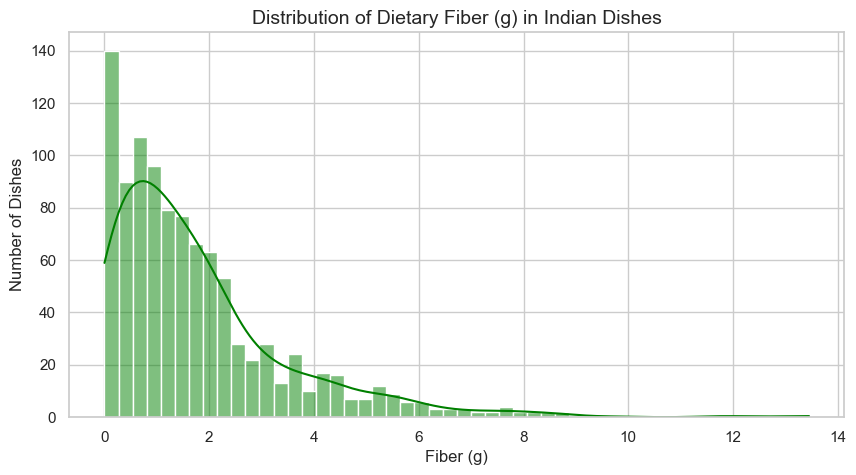

In [7]:
# Plot the distribution of Fiber (A positive DASH metric)
plt.figure(figsize=(10, 5))
sns.histplot(df['Fibre (g)'], bins=50, kde=True, color='green')
plt.title('Distribution of Dietary Fiber (g) in Indian Dishes', fontsize=14)
plt.xlabel('Fiber (g)', fontsize=12)
plt.ylabel('Number of Dishes', fontsize=12)
plt.show()

In [8]:
unsafe_threshold = 800
unsafe_dishes = df[df['Sodium (mg)'] > unsafe_threshold]

print(f"Filtering out {len(unsafe_dishes)} dishes that exceed {unsafe_threshold}mg of sodium.")

Filtering out 55 dishes that exceed 800mg of sodium.


In [9]:
safe_df = df[df['Sodium (mg)'] <= unsafe_threshold].copy()

## `PHASE 2: THE DASH SCORER`


In [10]:
metrics_to_scale = ['Fibre (g)', 'Calcium (mg)', 'Protein (g)', 'Sodium (mg)', 'Fats (g)', 'Free Sugar (g)']

scaler = MinMaxScaler()
safe_df_scaled = safe_df.copy()
safe_df_scaled[metrics_to_scale] = scaler.fit_transform(safe_df[metrics_to_scale])

# 3. The New, Mathematically Sound Scoring Logic
def calculate_normalized_dash_score(row):
    """
    Calculates DASH score using NORMALIZED data (0 to 1).
    Now the weights represent true relative importance.
    """
    fiber_points = row['Fibre (g)'] * 5.0       
    calcium_points = row['Calcium (mg)'] * 2.0  
    protein_points = row['Protein (g)'] * 1.0  
    
    sodium_penalty = row['Sodium (mg)'] * 4.0   
    fat_penalty = row['Fats (g)'] * 1.0         
    sugar_penalty = row['Free Sugar (g)'] * 3.0 
    
    total_score = (fiber_points + calcium_points + protein_points) - (sodium_penalty + fat_penalty + sugar_penalty)
    return round(total_score, 3)

safe_df['DASH_Score'] = safe_df_scaled.apply(calculate_normalized_dash_score, axis=1)

ranked_meals = safe_df.sort_values(by='DASH_Score', ascending=False)

In [11]:
display(ranked_meals[['Dish Name', 'DASH_Score', 'Sodium (mg)', 'Fibre (g)', 'Calcium (mg)', 'Calories (kcal)']].head(5))

,Dish Name,DASH_Score,Sodium (mg),Fibre (g),Calcium (mg),Calories (kcal)
927,Maa chaane ki dal,5.815,43.31,13.45,68.65,344.67
953,Cracked wheat and green gram dal premix (Dalia...,5.170,3.25,11.66,49.03,362.16
995,Mustard seeds baghar (Mustard seed tadka),3.744,8.90,9.74,182.93,552.59
319,Sesame ladoo (Til ke ladoo),3.724,18.55,7.72,631.82,396.96
682,Dessicated coconut chutney (Sookhe kase nariya...,3.532,321.07,13.16,73.55,346.36
